# Data Understanding & Exploratory Data Analysis (EDA)

**Project:** AI Fake News Detection System  
**Dataset:** WELFake / cleaned fake-news dataset  
**Objective:** Explore, clean, and understand the dataset before building or improving the model.

## Deliverables Covered
- Data Collection
- Data Cleaning
- Data Quality Assessment
- Exploratory Data Analysis (EDA)
- Feature Selection

## Required Output Covered
- Dataset Overview
- Missing Value Analysis
- Outlier Analysis
- Data Visualization
- Correlation Analysis
- Business Insights from Data

## 1. Setup

In [3]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_selection import chi2

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_colwidth', 120)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_PATH = PROJECT_ROOT / 'data' / 'raw' / 'WELFake_Dataset.csv'
CLEAN_PATH = PROJECT_ROOT / 'data' / 'processed' / 'cleaned_fake_news.csv'

print('Project root:', PROJECT_ROOT)
print('Raw dataset exists:', RAW_PATH.exists(), RAW_PATH)
print('Clean dataset exists:', CLEAN_PATH.exists(), CLEAN_PATH)

ImportError: Error importing numpy: you should not try to import numpy from
        its source directory; please exit the numpy source tree, and relaunch
        your python interpreter from there.

## 2. Data Collection

The project uses the WELFake dataset stored locally in `data/raw/WELFake_Dataset.csv`. A cleaned version used by the Streamlit app and baseline model is stored in `data/processed/cleaned_fake_news.csv`.

Important label mapping used in this project:
- `0` = Real news
- `1` = Fake news

In [2]:
raw_df = pd.read_csv(RAW_PATH) if RAW_PATH.exists() else None
df = pd.read_csv(CLEAN_PATH)

print('Raw shape:', raw_df.shape if raw_df is not None else 'Raw file not found')
print('Clean shape:', df.shape)
display(df.head())

Raw shape: (72134, 4)
Clean shape: (63676, 4)


,title,text,combined_text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terr...,No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called...,LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terr...,1
1,NaN,Did they post their votes for Hillary already?,. Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In Her Home State Of N...,"Now, most of the demonstrators gathered last night were exercising their constitutional and protected right to peace...",UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In Her Home State Of N...,1
3,"Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 2016 bid",A dozen politically active pastors came here for a private dinner Friday night to hear a conversion story unique in ...,"Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 2016 bid. A dozen p...",0
4,SATAN 2: Russia unvelis an image of its terrifying new ‘SUPERNUKE’ – Western world takes notice,"The RS-28 Sarmat missile, dubbed Satan 2, will replace the SS-18 Flies at 4.3 miles (7km) per sec and with a range o...",SATAN 2: Russia unvelis an image of its terrifying new ‘SUPERNUKE’ – Western world takes notice. The RS-28 Sarmat mi...,1


## 3. Dataset Overview

In [3]:
overview = pd.DataFrame({
    'rows': [len(df)],
    'columns': [df.shape[1]],
    'duplicate_rows': [df.duplicated().sum()],
    'unique_titles': [df['title'].nunique(dropna=True)],
    'unique_texts': [df['text'].nunique(dropna=True)],
})
display(overview)

schema = pd.DataFrame({
    'column': df.columns,
    'dtype': [df[col].dtype for col in df.columns],
    'non_null_count': [df[col].notna().sum() for col in df.columns],
    'unique_values': [df[col].nunique(dropna=True) for col in df.columns],
})
display(schema)

label_map = {0: 'Real News', 1: 'Fake News'}
label_counts = df['label'].map(label_map).value_counts().rename_axis('class').reset_index(name='count')
label_counts['percentage'] = (label_counts['count'] / len(df) * 100).round(2)
display(label_counts)

,rows,columns,duplicate_rows,unique_titles,unique_texts
0,63676,4,0,62338,62704


,column,dtype,non_null_count,unique_values
0,title,object,63158,62338
1,text,object,63108,62704
2,combined_text,object,63676,63676
3,label,int64,63676,2


,class,count,percentage
0,Real News,34790,54.64
1,Fake News,28886,45.36


## 4. Data Cleaning Review

The cleaned dataset keeps the core fields needed for text classification:
- `title`
- `text`
- `combined_text`
- `label`

This section checks whether additional cleaning is required before modeling.

In [4]:
df = df.copy()
for col in ['title', 'text', 'combined_text']:
    df[col] = df[col].fillna('').astype(str).str.strip()

df['label_name'] = df['label'].map(label_map)
df['title_length_chars'] = df['title'].str.len()
df['text_length_chars'] = df['text'].str.len()
df['combined_length_chars'] = df['combined_text'].str.len()
df['title_word_count'] = df['title'].str.split().str.len()
df['text_word_count'] = df['text'].str.split().str.len()
df['combined_word_count'] = df['combined_text'].str.split().str.len()
df['uppercase_ratio'] = df['combined_text'].apply(lambda x: sum(c.isupper() for c in x) / max(sum(c.isalpha() for c in x), 1))
df['punctuation_count'] = df['combined_text'].str.count(r'[^\w\s]')
df['digit_count'] = df['combined_text'].str.count(r'\d')
df['has_url'] = df['combined_text'].str.contains(r'https?://|www\.', case=False, regex=True)
df['has_breaking'] = df['combined_text'].str.contains('breaking', case=False, regex=False)

display(df[['title', 'text', 'label_name', 'combined_word_count', 'uppercase_ratio', 'punctuation_count']].head())

,title,text,label_name,combined_word_count,uppercase_ratio,punctuation_count
0,LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terr...,No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called...,Fake News,889,0.051763,188
1,,Did they post their votes for Hillary already?,Fake News,9,0.052632,2
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MOST CHARLOTTE RIOTERS WERE “PEACEFUL” PROTESTERS…In Her Home State Of N...,"Now, most of the demonstrators gathered last night were exercising their constitutional and protected right to peace...",Fake News,52,0.331034,10
3,"Bobby Jindal, raised Hindu, uses story of Christian conversion to woo evangelicals for potential 2016 bid",A dozen politically active pastors came here for a private dinner Friday night to hear a conversion story unique in ...,Real News,1337,0.038456,212
4,SATAN 2: Russia unvelis an image of its terrifying new ‘SUPERNUKE’ – Western world takes notice,"The RS-28 Sarmat missile, dubbed Satan 2, will replace the SS-18 Flies at 4.3 miles (7km) per sec and with a range o...",Fake News,345,0.090143,55


## 5. Missing Value Analysis

,missing_count,missing_percentage
text,568,0.89
title,518,0.81
combined_text,0,0.00
label,0,0.00
label_name,0,0.00
title_length_chars,0,0.00
text_length_chars,0,0.00
combined_length_chars,0,0.00
title_word_count,0,0.00
text_word_count,0,0.00


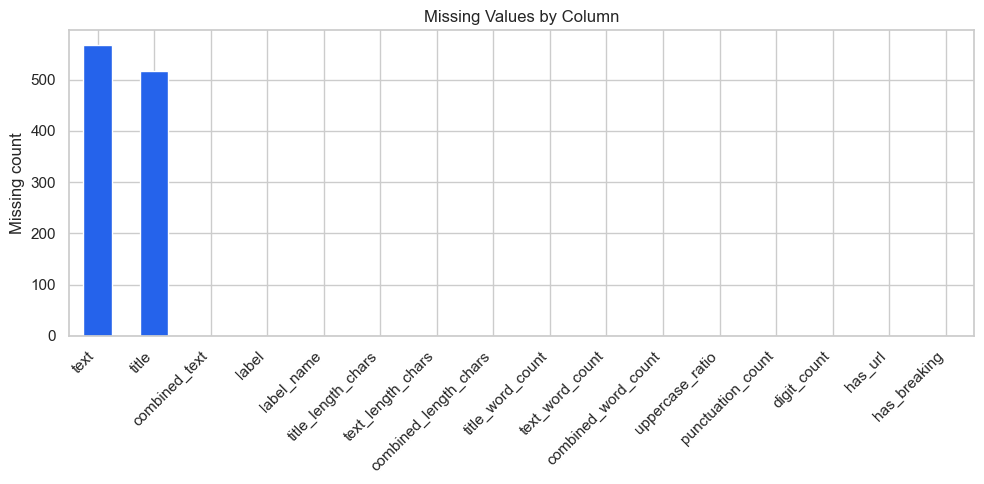

In [5]:
missing = pd.DataFrame({
    'missing_count': df.replace('', np.nan).isna().sum(),
    'missing_percentage': (df.replace('', np.nan).isna().mean() * 100).round(2),
}).sort_values('missing_count', ascending=False)
display(missing)

missing[['missing_count']].plot(kind='bar', legend=False, color='#2563EB')
plt.title('Missing Values by Column')
plt.ylabel('Missing count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Data Quality Assessment

Quality checks include empty text, duplicated content, extremely short articles, and label balance.

In [6]:
quality = pd.DataFrame({
    'check': [
        'Empty title',
        'Empty text',
        'Empty combined text',
        'Duplicated title + text',
        'Very short combined text (< 20 words)',
        'Very long combined text (> 99th percentile)',
    ],
    'count': [
        (df['title'] == '').sum(),
        (df['text'] == '').sum(),
        (df['combined_text'] == '').sum(),
        df.duplicated(subset=['title', 'text']).sum(),
        (df['combined_word_count'] < 20).sum(),
        (df['combined_word_count'] > df['combined_word_count'].quantile(0.99)).sum(),
    ]
})
quality['percentage'] = (quality['count'] / len(df) * 100).round(2)
display(quality)

display(df[df['combined_word_count'] < 20][['title', 'text', 'label_name', 'combined_word_count']].head(10))

,check,count,percentage
0,Empty title,518,0.81
1,Empty text,568,0.89
2,Empty combined text,0,0.00
3,Duplicated title + text,0,0.00
4,Very short combined text (< 20 words),928,1.46
5,Very long combined text (> 99th percentile),637,1.00


,title,text,label_name,combined_word_count
1,,Did they post their votes for Hillary already?,Fake News,9
7,HOUSE INTEL CHAIR On Trump-Russia Fake Story: “No evidence of anything” [Video],,Fake News,12
43,,"True. Hillary needs a distraction and what better than a real ""wag the dog"" with Russia.",Fake News,17
79,‘Arab Spring’ and the Washington-Brussels-Riyadh Axis,Be the First to Comment! Search articles,Fake News,13
106,MARKETWATCH LEFTIST: MSM’s “Blatant” Anti Trump Bias May Be Suicidal,,Fake News,10
162,,All eyes on Electoral delegates. The People know where they live!,Fake News,12
185,,Cool,Fake News,2
244,WORLD WAR 3 IS COMING,source Add To The Conversation Using Facebook Comments,Fake News,13
325,Ohio State University Student Says Terrorist Attack Was “Misunderstanding” Caused By Racism [VIDEO],,Fake News,13
358,,Obamas blunder.,Fake News,3


## 7. Outlier Analysis

For text data, outliers are usually unusually short or unusually long documents. These can affect model training because very short records give little evidence, while extremely long records may dominate vocabulary patterns.

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
title_word_count,63676.0,11.892330,3.974623,0.0,2.750000,7.000000,9.000000,11.000000,14.000000,18.000000,24.000000,72.0
text_word_count,63676.0,542.301181,610.398839,0.0,1.000000,52.000000,235.000000,403.000000,673.000000,1400.000000,2665.500000,24234.0
combined_word_count,63676.0,554.201646,610.742413,2.0,15.000000,62.000000,247.000000,414.000000,685.000000,1413.250000,2680.500000,24243.0
uppercase_ratio,63676.0,0.062241,0.060951,0.0,0.021868,0.028781,0.039473,0.049012,0.064364,0.122618,0.333333,1.0
punctuation_count,63676.0,93.374772,118.844525,1.0,4.000000,11.000000,37.000000,63.000000,114.000000,259.000000,494.000000,7219.0


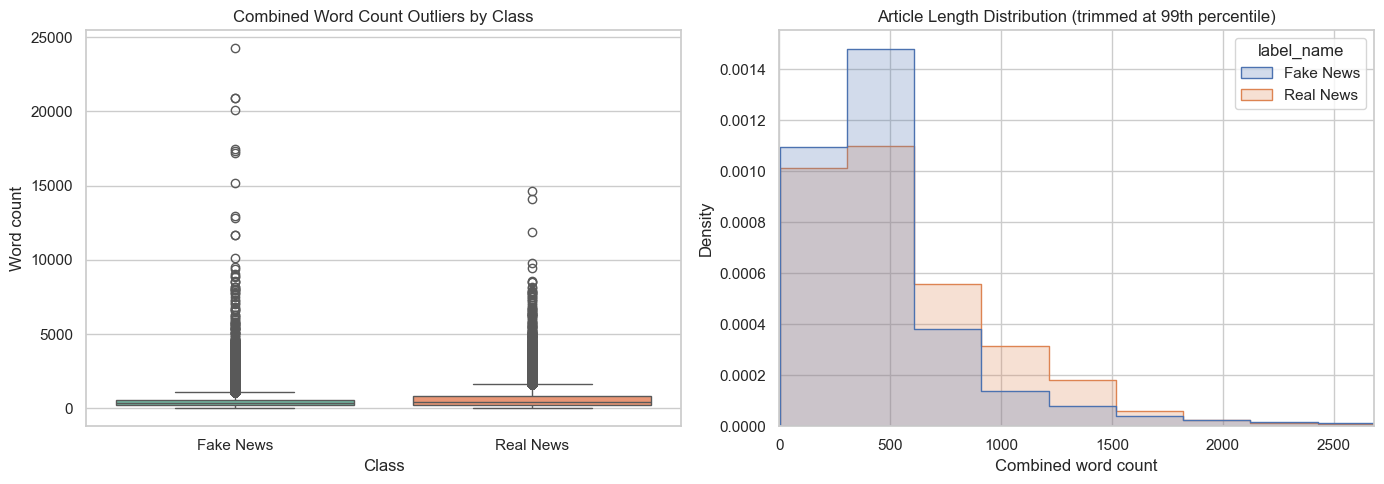

In [7]:
length_features = ['title_word_count', 'text_word_count', 'combined_word_count', 'uppercase_ratio', 'punctuation_count']
display(df[length_features].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='label_name', y='combined_word_count', ax=axes[0], palette='Set2')
axes[0].set_title('Combined Word Count Outliers by Class')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Word count')

sns.histplot(data=df, x='combined_word_count', hue='label_name', bins=80, ax=axes[1], element='step', stat='density', common_norm=False)
axes[1].set_xlim(0, df['combined_word_count'].quantile(0.99))
axes[1].set_title('Article Length Distribution (trimmed at 99th percentile)')
axes[1].set_xlabel('Combined word count')
plt.tight_layout()
plt.show()

## 8. Data Visualization

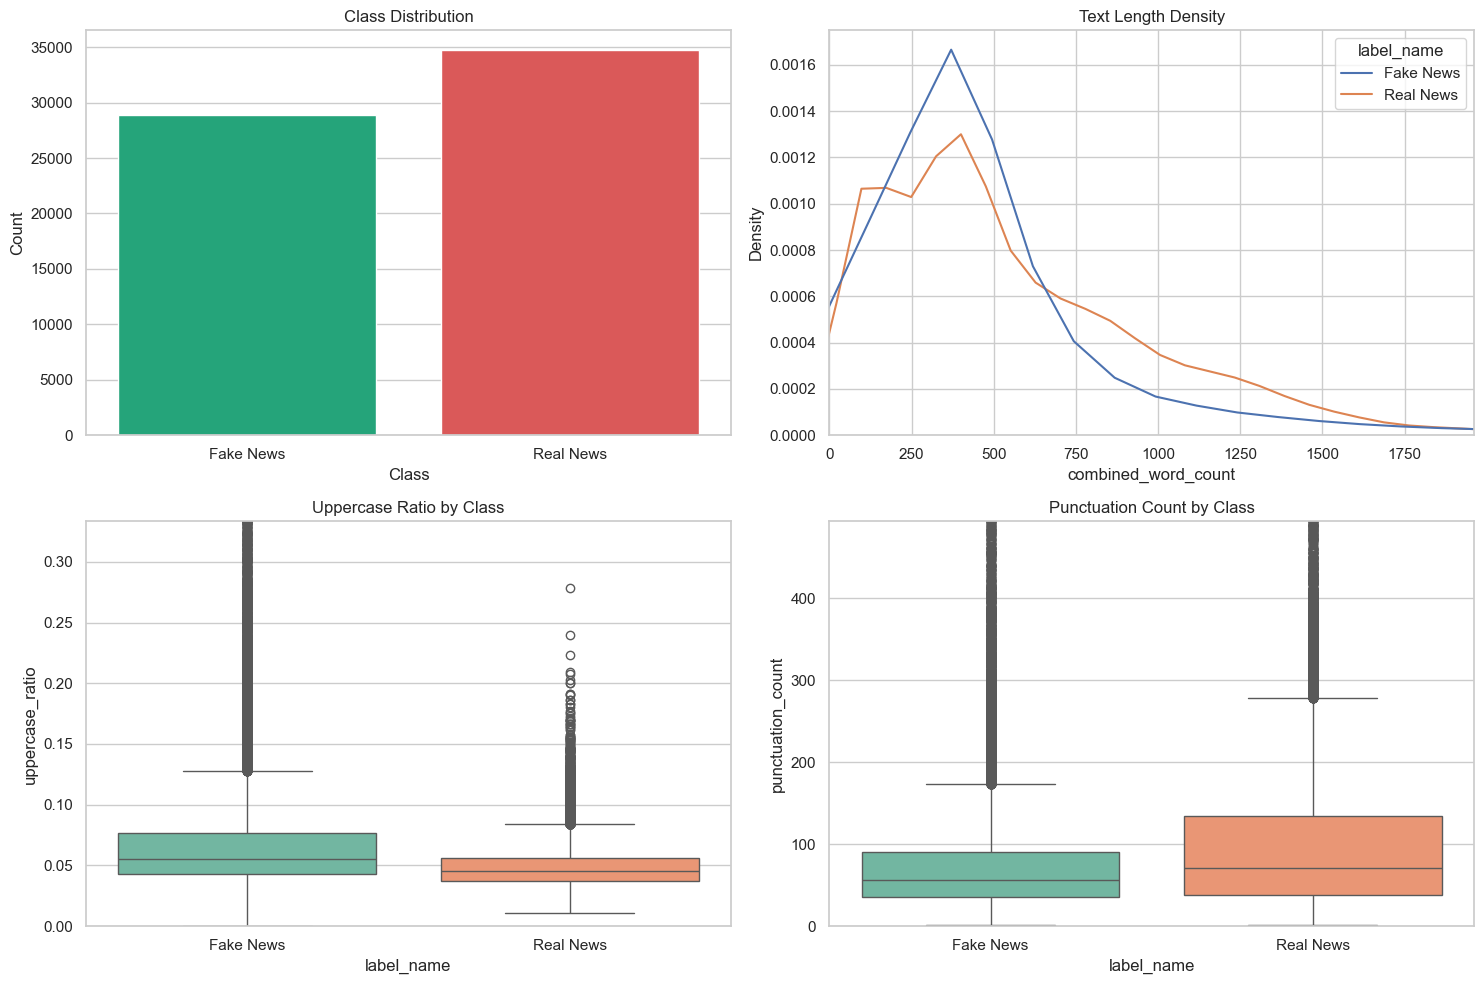

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=df, x='label_name', ax=axes[0, 0], palette=['#10B981', '#EF4444'])
axes[0, 0].set_title('Class Distribution')
axes[0, 0].set_xlabel('Class')
axes[0, 0].set_ylabel('Count')

sns.kdeplot(data=df, x='combined_word_count', hue='label_name', ax=axes[0, 1], common_norm=False)
axes[0, 1].set_xlim(0, df['combined_word_count'].quantile(0.98))
axes[0, 1].set_title('Text Length Density')

sns.boxplot(data=df, x='label_name', y='uppercase_ratio', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Uppercase Ratio by Class')
axes[1, 0].set_ylim(0, df['uppercase_ratio'].quantile(0.99))

sns.boxplot(data=df, x='label_name', y='punctuation_count', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Punctuation Count by Class')
axes[1, 1].set_ylim(0, df['punctuation_count'].quantile(0.99))

plt.tight_layout()
plt.show()

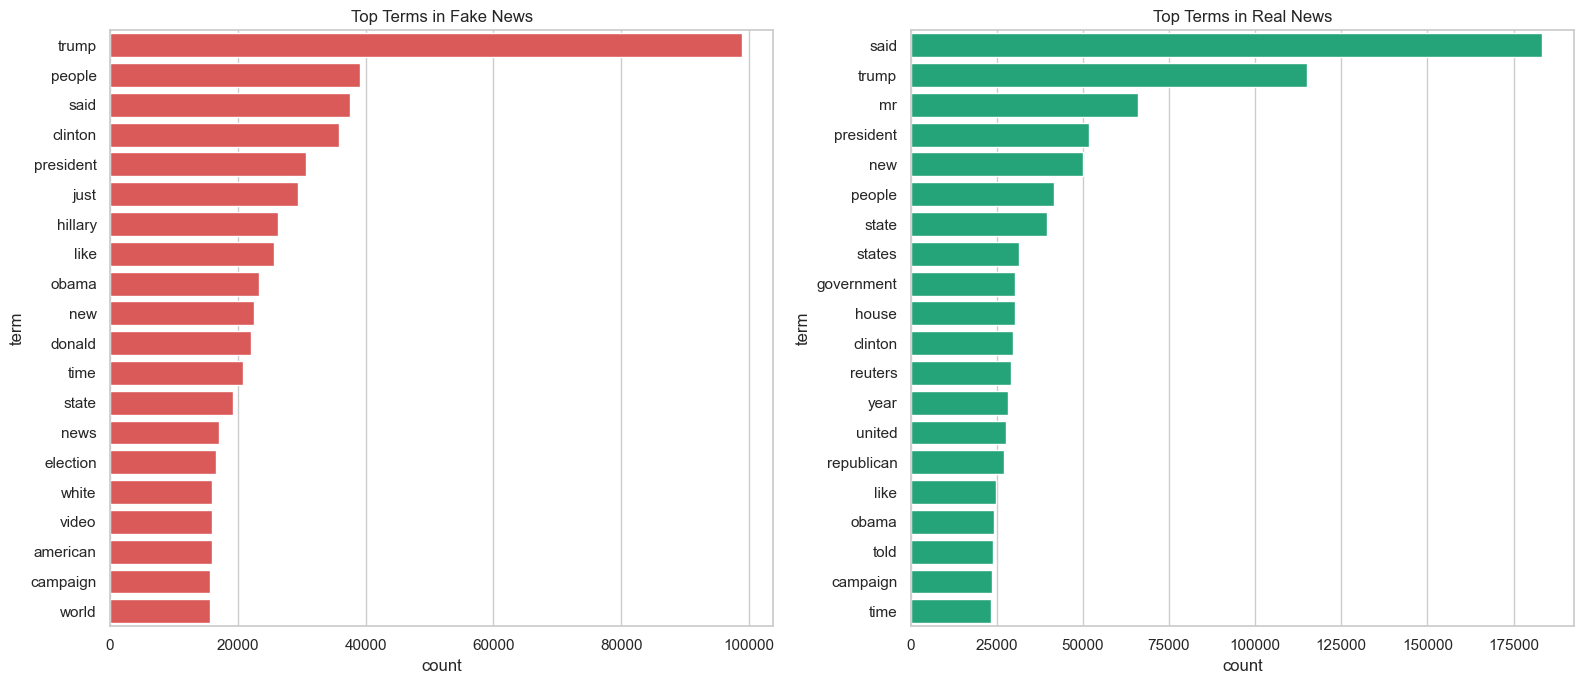

In [9]:
def top_terms_by_class(data, label_value, n=20):
    subset = data.loc[data['label'] == label_value, 'combined_text'].dropna().astype(str)
    vectorizer = CountVectorizer(stop_words='english', max_features=5000, ngram_range=(1, 1), min_df=5)
    matrix = vectorizer.fit_transform(subset)
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()
    result = pd.DataFrame({'term': terms, 'count': counts}).sort_values('count', ascending=False).head(n)
    return result

fake_terms = top_terms_by_class(df, 1, 20)
real_terms = top_terms_by_class(df, 0, 20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(data=fake_terms, y='term', x='count', ax=axes[0], color='#EF4444')
axes[0].set_title('Top Terms in Fake News')

sns.barplot(data=real_terms, y='term', x='count', ax=axes[1], color='#10B981')
axes[1].set_title('Top Terms in Real News')

plt.tight_layout()
plt.show()

## 9. Correlation Analysis

For text classification, correlation is calculated on engineered numeric features rather than raw text. Positive correlation with `label` means stronger association with fake news (`1`). Negative correlation means stronger association with real news (`0`).

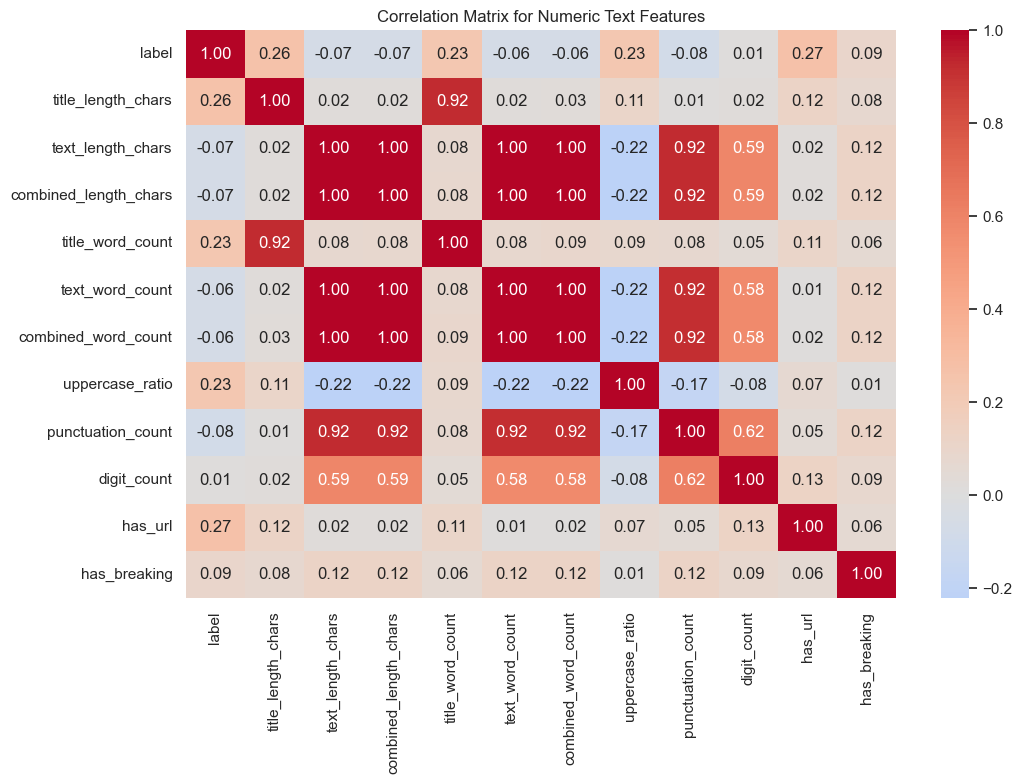

,feature,correlation_with_fake_label
0,has_url,0.266230
1,title_length_chars,0.261264
2,uppercase_ratio,0.233004
3,title_word_count,0.231942
4,has_breaking,0.094537
5,punctuation_count,-0.082796
6,text_length_chars,-0.067022
7,combined_length_chars,-0.065323
8,text_word_count,-0.064663
9,combined_word_count,-0.063103


In [10]:
numeric_features = [
    'label',
    'title_length_chars',
    'text_length_chars',
    'combined_length_chars',
    'title_word_count',
    'text_word_count',
    'combined_word_count',
    'uppercase_ratio',
    'punctuation_count',
    'digit_count',
    'has_url',
    'has_breaking',
]
corr_df = df[numeric_features].copy()
corr_df['has_url'] = corr_df['has_url'].astype(int)
corr_df['has_breaking'] = corr_df['has_breaking'].astype(int)

correlation = corr_df.corr(numeric_only=True)
plt.figure(figsize=(11, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix for Numeric Text Features')
plt.tight_layout()
plt.show()

label_corr = correlation['label'].drop('label').sort_values(key=lambda s: s.abs(), ascending=False).reset_index()
label_corr.columns = ['feature', 'correlation_with_fake_label']
display(label_corr)

## 10. Feature Selection

This section uses TF-IDF and chi-square scores to find terms most associated with the fake/real label. These are useful for understanding the dataset and for selecting text features for classical models such as Logistic Regression.

In [11]:
sample_for_features = df.sample(min(len(df), 30000), random_state=42)
tfidf = TfidfVectorizer(
    max_features=20000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=5,
)
X = tfidf.fit_transform(sample_for_features['combined_text'].astype(str))
y = sample_for_features['label'].astype(int)
scores, p_values = chi2(X, y)
features = np.array(tfidf.get_feature_names_out())

feature_scores = pd.DataFrame({
    'feature': features,
    'chi2_score': scores,
    'p_value': p_values,
}).sort_values('chi2_score', ascending=False)

display(feature_scores.head(30))

,feature,chi2_score,p_value
15263,said,304.848037,2.894510e-68
14802,reuters,249.418318,3.477381e-56
11311,mr,246.624369,1.413765e-55
19072,video,240.653253,2.833140e-54
8080,hillary,190.220515,2.845755e-43
6582,featured image,142.946619,6.038131e-33
8464,image,137.638284,8.743733e-32
6581,featured,133.862802,5.854450e-31
18622,twitter com,126.587951,2.286409e-29
3540,com,116.150102,4.406504e-27


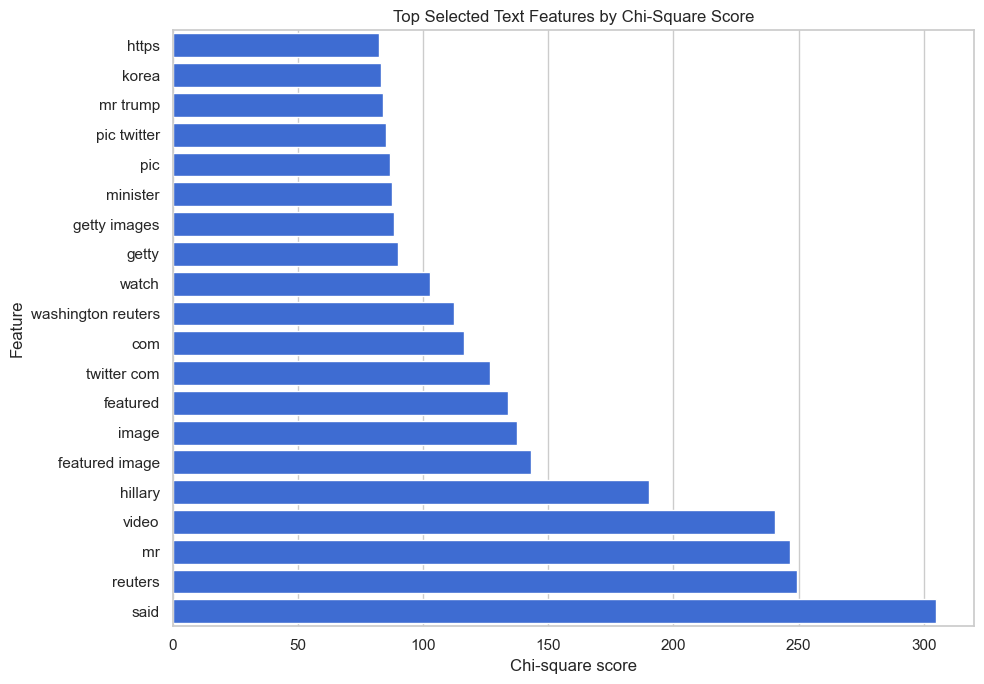

In [12]:
top_selected = feature_scores.head(20).sort_values('chi2_score')
plt.figure(figsize=(10, 7))
sns.barplot(data=top_selected, x='chi2_score', y='feature', color='#2563EB')
plt.title('Top Selected Text Features by Chi-Square Score')
plt.xlabel('Chi-square score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 11. Business Insights from Data

In [13]:
fake_df = df[df['label'] == 1]
real_df = df[df['label'] == 0]

insights = []
fake_pct = len(fake_df) / len(df) * 100
real_pct = len(real_df) / len(df) * 100
insights.append(f"Dataset is reasonably balanced: {fake_pct:.1f}% fake and {real_pct:.1f}% real.")

fake_len = fake_df['combined_word_count'].median()
real_len = real_df['combined_word_count'].median()
insights.append(f"Median article length differs by class: fake median = {fake_len:.0f} words, real median = {real_len:.0f} words.")

fake_upper = fake_df['uppercase_ratio'].median()
real_upper = real_df['uppercase_ratio'].median()
insights.append(f"Uppercase writing pattern differs by class: fake median uppercase ratio = {fake_upper:.3f}, real = {real_upper:.3f}.")

short_fake_rate = (fake_df['combined_word_count'] < 20).mean() * 100
short_real_rate = (real_df['combined_word_count'] < 20).mean() * 100
insights.append(f"Very short content is a quality risk: {short_fake_rate:.2f}% of fake records and {short_real_rate:.2f}% of real records have fewer than 20 words.")

top_feature_list = ', '.join(feature_scores.head(10)['feature'].tolist())
insights.append(f"Top predictive text features from chi-square include: {top_feature_list}.")

for i, insight in enumerate(insights, start=1):
    print(f"{i}. {insight}")

1. Dataset is reasonably balanced: 45.4% fake and 54.6% real.
2. Median article length differs by class: fake median = 387 words, real median = 438 words.
3. Uppercase writing pattern differs by class: fake median uppercase ratio = 0.055, real = 0.045.
4. Very short content is a quality risk: 3.10% of fake records and 0.09% of real records have fewer than 20 words.
5. Top predictive text features from chi-square include: said, reuters, mr, video, hillary, featured image, image, featured, twitter com, com.


## 12. Recommendations Before Modeling

1. Keep the label mapping consistent: `0 = Real`, `1 = Fake`.
2. Remove or review extremely short records because they provide weak evidence for the classifier.
3. Track text length, uppercase ratio, punctuation count, and suspicious phrase indicators as optional engineered features.
4. Use TF-IDF n-grams for the baseline model because they capture useful fake/real wording patterns.
5. For business use, present model output as a risk signal, not as absolute truth. High-risk items should be verified with official or trusted sources.